In [1]:
pip install tensorflow matplotlib numpy scikit-learn

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [5]:
# Cell 3: Load Fashion-MNIST dataset
# Explanation: Fashion-MNIST is built into Keras. It has 60k train, 10k test images (28x28 grayscale).
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']
print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


In [7]:
import numpy as np
import tensorflow as tf

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize & reshape
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [9]:
# Cell 5: Preprocess data
# Normalize pixel values to [0,1] and add channel dimension for Conv2D (N,28,28,1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)
print("Input shape for model:", x_train.shape[1:])

Input shape for model: (28, 28, 1, 1)


In [11]:
from tensorflow.keras import layers, models

def build_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Cell 7: Train the model
# Explanation: Train for ~10 epochs. You can change batch_size or epochs.
EPOCHS = 10
BATCH_SIZE = 128

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=2
)

Epoch 1/10
422/422 - 135s - 321ms/step - accuracy: 0.4687 - loss: 1.4472 - val_accuracy: 0.7070 - val_loss: 0.8162
Epoch 2/10
422/422 - 116s - 276ms/step - accuracy: 0.6875 - loss: 0.8459 - val_accuracy: 0.7328 - val_loss: 0.7121
Epoch 3/10
422/422 - 85s - 202ms/step - accuracy: 0.7171 - loss: 0.7607 - val_accuracy: 0.7542 - val_loss: 0.6581
Epoch 4/10
422/422 - 77s - 184ms/step - accuracy: 0.7311 - loss: 0.7165 - val_accuracy: 0.7598 - val_loss: 0.6304
Epoch 5/10
422/422 - 79s - 188ms/step - accuracy: 0.7433 - loss: 0.6842 - val_accuracy: 0.7663 - val_loss: 0.6112
Epoch 6/10
422/422 - 82s - 195ms/step - accuracy: 0.7516 - loss: 0.6576 - val_accuracy: 0.7835 - val_loss: 0.5778
Epoch 7/10
422/422 - 83s - 198ms/step - accuracy: 0.7614 - loss: 0.6370 - val_accuracy: 0.7888 - val_loss: 0.5507
Epoch 8/10
422/422 - 83s - 198ms/step - accuracy: 0.7682 - loss: 0.6141 - val_accuracy: 0.7867 - val_loss: 0.5446
Epoch 9/10
422/422 - 86s - 204ms/step - accuracy: 0.7761 - loss: 0.5953 - val_accuracy

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

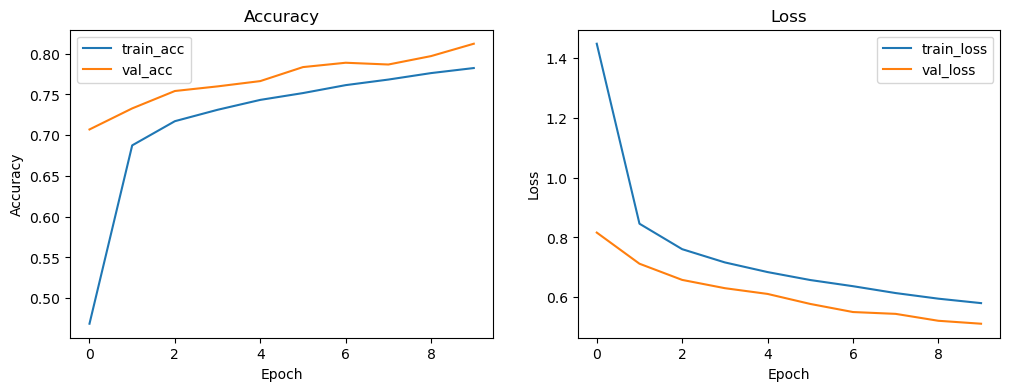

In [19]:
# Cell 8: Plot training curves (accuracy & loss)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('Loss')
plt.show()

In [21]:
# Cell 9: Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

313/313 - 3s - 11ms/step - accuracy: 0.7978 - loss: 0.5428
Test accuracy: 0.7978, Test loss: 0.5428


In [23]:
# Cell 9: Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

313/313 - 3s - 10ms/step - accuracy: 0.7978 - loss: 0.5428
Test accuracy: 0.7978, Test loss: 0.5428


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

In [31]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [33]:
# Cell 10: Predictions + classification report
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

 T-shirt/top     0.7512    0.7730    0.7620      1000
     Trouser     0.9766    0.9200    0.9475      1000
    Pullover     0.6185    0.6810    0.6483      1000
       Dress     0.7549    0.8500    0.7996      1000
        Coat     0.6117    0.7720    0.6826      1000
      Sandal     0.9409    0.9080    0.9242      1000
       Shirt     0.5230    0.2610    0.3482      1000
     Sneaker     0.9026    0.9080    0.9053      1000
         Bag     0.9200    0.9540    0.9367      1000
  Ankle boot     0.9206    0.9510    0.9356      1000

    accuracy                         0.7978     10000
   macro avg     0.7920    0.7978    0.7890     10000
weighted avg     0.7920    0.7978    0.7890     10000



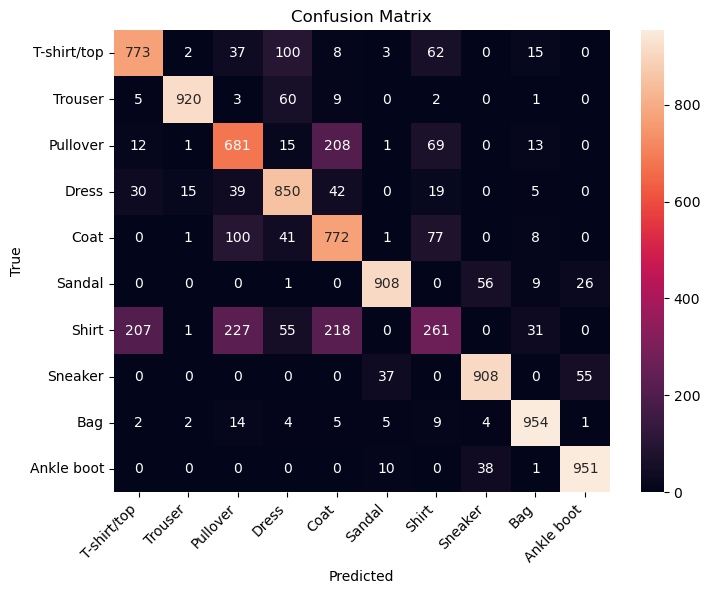

In [35]:
# Cell 11: Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xticks(rotation=45, ha='right')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.title('Confusion Matrix')
plt.show()


In [39]:
import matplotlib.pyplot as plt
import random

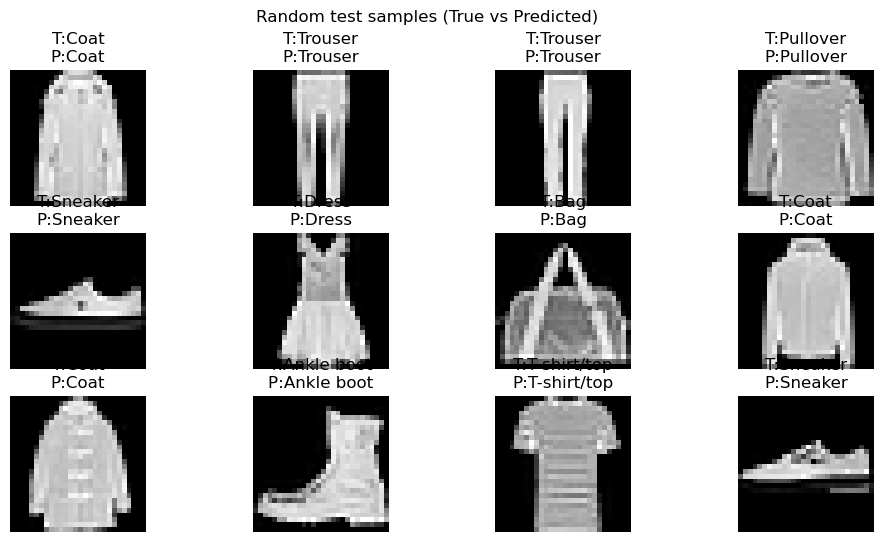

In [41]:
# Cell 12: Show sample correct and incorrect predictions
# Pick random test images and show predicted vs true labels
num = 12
indices = random.sample(range(len(x_test)), num)
plt.figure(figsize=(12,6))
for i, idx in enumerate(indices):
    ax = plt.subplot(3,4,i+1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis('off')
plt.suptitle('Random test samples (True vs Predicted)')
plt.show()

In [43]:
# Cell 13: Save the trained model
model.save("fashion_mnist_cnn.h5")
print("Model saved to fashion_mnist_cnn.h5")

Model saved to fashion_mnist_cnn.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted: Ankle boot Prob: 0.735


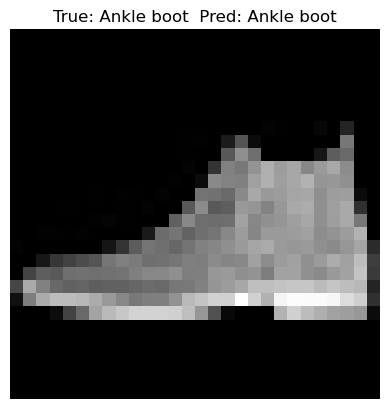

In [45]:
# Cell 14: Inference on a single image (from test set) - demonstration
# Replace index below to test different images
idx = 0
img = x_test[idx]  # already normalized & shaped (28,28,1)
prob = model.predict(img[np.newaxis, ...])[0]
pred_label = np.argmax(prob)
print("Predicted:", class_names[pred_label], "Prob:", np.round(prob[pred_label], 3))
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"True: {class_names[y_test[idx]]}  Pred: {class_names[pred_label]}")
plt.axis('off')
plt.show()

In [47]:
# Cell 15: How to use your own image (1) - load an external image file (example)
# Save an image named 'my_cloth.png' in the notebook folder and run this.
from PIL import Image
def preprocess_external_image(path):
    img = Image.open(path).convert('L')  # convert to grayscale
    img = img.resize((28,28))
    arr = np.array(img).astype('float32') / 255.0
    arr = np.expand_dims(arr, -1)
    return arr

# example usage:
# my_img = preprocess_external_image('my_cloth.png')
# pred = model.predict(np.expand_dims(my_img,0))[0]
# print("Predicted:", class_names[np.argmax(pred)])

In [51]:
import numpy as np

print("Before fix:", x_train.shape)

# If x_train has an extra singleton dimension, remove it safely
if x_train.ndim == 5:
    # remove the last axis only (so (N,28,28,1,1) -> (N,28,28,1))
    x_train = np.squeeze(x_train, axis=-1)
elif x_train.ndim == 3:
    # if somehow it's (N,28,28) -> add channel dim
    x_train = np.expand_dims(x_train, -1)

print("After fix:", x_train.shape)

Before fix: (60000, 28, 28, 1, 1)
After fix: (60000, 28, 28, 1)


In [53]:
# (Optional) Cell 16: Quick augmentation & retrain tip (if you want small improvement)
# Use ImageDataGenerator from Keras to augment (shifts, small rotations)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rotation_range=10, width_shift_range=0.08, height_shift_range=0.08, horizontal_flip=False)
datagen.fit(x_train)
# Example to use: model.fit(datagen.flow(x_train,y_train,batch_size=128), epochs=6, validation_data=(x_test,y_test))

## GUI added by assistant
A robust ipywidgets-based GUI cell has been appended below. Run the cell to get a file-upload widget and prediction button. If you see any errors, read the printed diagnostics in the output. If you prefer the GUI in a different place, move or copy the cell.

In [1]:
# Clean & Correct GUI for Fashion-MNIST
import io, traceback, sys
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display, clear_output

MODEL_PATH = "fashion_mnist_cnn.h5"

class_names = [
    'T-shirt/top','Trouser','Pullover','Dress','Coat',
    'Sandal','Shirt','Sneaker','Bag','Ankle boot'
]

# Load model
load_err = None
model = None
try:
    from tensorflow.keras.models import load_model
    model = load_model(MODEL_PATH)
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    print(f"Loaded model from {MODEL_PATH}")
except Exception as e:
    load_err = traceback.format_exc()
    print("Model load error:\n", load_err)

def preprocess_pil_image(pil_img):
    img = pil_img.convert('L').resize((28,28))
    arr = np.array(img).astype('float32') / 255.0
    arr = np.expand_dims(arr, -1)
    return arr

def predict_image(img_arr):
    pred_probs = model.predict(np.expand_dims(img_arr, 0))[0]
    idx = int(np.argmax(pred_probs))
    return idx, pred_probs

# Widgets
uploader = widgets.FileUpload(accept='image/*', multiple=False)
predict_btn = widgets.Button(description="Predict", button_style='success')
out = widgets.Output(layout={'border': '1px solid black',
                             'max_height': '400px',
                             'overflow': 'auto'})

def on_predict_clicked(b):
    with out:
        clear_output()

        if load_err:
            print("Model failed to load:\n")
            print(load_err)
            return

        if not uploader.value:
            print("Please upload an image first.")
            return

        try:
            # ipywidgets 8.x gives a tuple of dicts
            file_obj = uploader.value[0]
            content = file_obj['content']

            pil_img = Image.open(io.BytesIO(content))

            # Show preview
            plt.figure(figsize=(3,3))
            plt.imshow(pil_img.convert('RGB'))
            plt.axis('off')
            plt.title("Uploaded image")
            plt.show()

            # Predict
            x = preprocess_pil_image(pil_img)
            idx, probs = predict_image(x)

            print(f"Predicted: {class_names[idx]} (confidence: {probs[idx]:.3f})\n")
            for i, name in enumerate(class_names):
                print(f"{name:12s}: {probs[i]:.3f}")

        except Exception:
            print("An exception occurred:")
            traceback.print_exc()

predict_btn.on_click(on_predict_clicked)

# Display GUI
display(widgets.VBox([
    widgets.HTML("<h3>Fashion-MNIST Image Predictor</h3>"),
    uploader,
    predict_btn,
    out
]))


Loaded model from fashion_mnist_cnn.h5
